# 03. CNN Modeling

이 노트북에서는 32x32로 resize된 wafer map 데이터를 사용하여 `non_pattern`과 `pattern`을 분류하는 CNN 모델을 학습한다.

Baseline 모델인 Logistic Regression과 Random Forest는 wafer map을 1차원 feature vector로 펼쳐 사용했기 때문에 공간 구조를 충분히 반영하지 못할 수 있다. CNN은 wafer map의 2차원 공간 패턴을 직접 학습할 수 있는지 확인하기 위해 사용한다.

In [2]:
import sys

!{sys.executable} -m pip install tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.2/223.2 MB 5.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 9.6 MB/s eta 0:00:00ta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 8.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.8/566.8 kB 8.7 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 9.5 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.3/82.3 kB 6.6 MB/s eta 0:00:00
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl (26 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 453.3/453.3 kB 9.2 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 9.6 MB/s eta 0:00:0000:0100:01
  Using cached requests-2.34.2-py3-none-any.whl (73 kB)
     ━━━━━━━

In [3]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import tensorflow as tf

from sklearn.metrics import classification_report, confusion_matrix

In [5]:
processed_dir = Path("../data/processed")

X_train = np.load(processed_dir / "X_train_32.npy")
X_test = np.load(processed_dir / "X_test_32.npy")
y_train = np.load(processed_dir / "y_train_pattern.npy")
y_test = np.load(processed_dir / "y_test_pattern.npy")

label_info = pd.read_csv(processed_dir / "pattern_label_mapping.csv")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nlabel mapping:")
display(label_info)

X_train shape: (54355, 32, 32, 1)
X_test shape: (118595, 32, 32, 1)
y_train shape: (54355,)
y_test shape: (118595,)

label mapping:


,class_index,class_name
0,0,non_pattern
1,1,pattern


In [6]:
print("Train label distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTest label distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Train label distribution:
0    36730
1    17625
Name: count, dtype: int64

Test label distribution:
0    110701
1      7894
Name: count, dtype: int64


In [7]:
from tensorflow.keras import layers, models

cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 1)),

    layers.Conv2D(16, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,657 (307.25 KB)

 Trainable params: 78,657 (307.25 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = cnn_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=256,
    verbose=1
)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8136 - loss: 0.3953 - precision: 0.8374 - recall: 0.6668 - val_accuracy: 0.7602 - val_loss: 0.4347 - val_precision: 0.0207 - val_recall: 0.4954
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9137 - loss: 0.2199 - precision: 0.9068 - recall: 0.8757 - val_accuracy: 0.8471 - val_loss: 0.2771 - val_precision: 0.0314 - val_recall: 0.4771
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9264 - loss: 0.1902 - precision: 0.9226 - recall: 0.8922 - val_accuracy: 0.7882 - val_loss: 0.3488 - val_precision: 0.0239 - val_recall: 0.5046
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9366 - loss: 0.1674 - precision: 0.9365 - recall: 0.9040 - val_accuracy: 0.7512 - val_loss: 0.4266 - val_precision: 0.0238 - val_recall: 0.5963
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9417 - loss: 0.1568 - precision: 0.9433 - recall: 0.9099 - val_accuracy: 0.9418 - val_loss: 0.

In [9]:
y_proba_cnn = cnn_model.predict(X_test).ravel()

y_pred_cnn = (y_proba_cnn >= 0.5).astype(int)

print("CNN Classification Report:")
print(classification_report(
    y_test,
    y_pred_cnn,
    target_names=label_info["class_name"].tolist()
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_cnn))

3707/3707 ━━━━━━━━━━━━━━━━━━━━ 4s 953us/step
CNN Classification Report:
              precision    recall  f1-score   support

 non_pattern       0.96      0.85      0.90    110701
     pattern       0.20      0.50      0.28      7894

    accuracy                           0.83    118595
   macro avg       0.58      0.68      0.59    118595
weighted avg       0.91      0.83      0.86    118595

Confusion Matrix:
[[94573 16128]
 [ 3978  3916]]


## CNN모델 구조

입력: 32 × 32 × 1 wafer map image
↓
Conv2D 16 filters
↓
MaxPooling2D
↓
Conv2D 32 filters
↓
MaxPooling2D
↓
Flatten
↓
Dense 64
↓
Dropout 0.3
↓
Dense 1 sigmoid
↓
출력: pattern일 확률

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

cnn_threshold_results = []

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    y_pred_threshold = (y_proba_cnn >= threshold).astype(int)

    cnn_threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred_threshold),
        "pattern_precision": precision_score(y_test, y_pred_threshold, pos_label=1, zero_division=0),
        "pattern_recall": recall_score(y_test, y_pred_threshold, pos_label=1),
        "pattern_f1": f1_score(y_test, y_pred_threshold, pos_label=1),
        "predicted_pattern_count": np.sum(y_pred_threshold == 1)
    })

cnn_threshold_results = pd.DataFrame(cnn_threshold_results)

display(cnn_threshold_results)

,threshold,accuracy,pattern_precision,pattern_recall,pattern_f1,predicted_pattern_count
0,0.3,0.701842,0.132807,0.629212,0.219323,37400
1,0.4,0.776711,0.160982,0.559032,0.249979,27413
2,0.5,0.830465,0.195370,0.496073,0.280335,20044
3,0.6,0.869935,0.239177,0.437421,0.309256,14437
4,0.7,0.899271,0.298408,0.379909,0.334262,10050


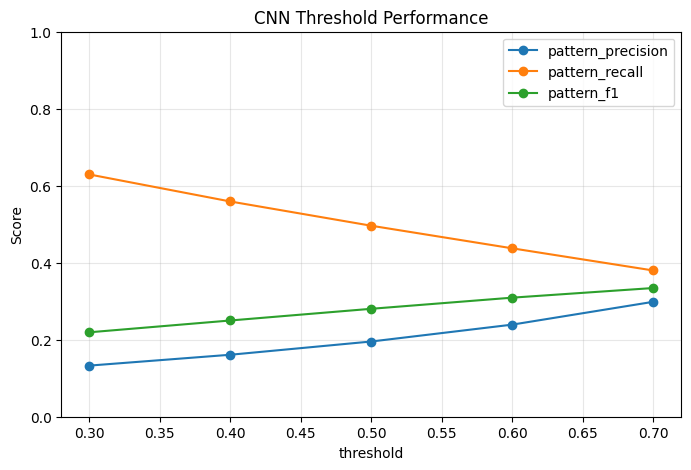

In [11]:
cnn_threshold_results.set_index("threshold")[["pattern_precision", "pattern_recall", "pattern_f1"]].plot(
    marker="o",
    figsize=(8, 5)
)

plt.title("CNN Threshold Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.show()

In [12]:
cnn_threshold_results = []

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for threshold in thresholds:
    y_pred_threshold = (y_proba_cnn >= threshold).astype(int)

    cnn_threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred_threshold),
        "pattern_precision": precision_score(y_test, y_pred_threshold, pos_label=1, zero_division=0),
        "pattern_recall": recall_score(y_test, y_pred_threshold, pos_label=1),
        "pattern_f1": f1_score(y_test, y_pred_threshold, pos_label=1),
        "predicted_pattern_count": np.sum(y_pred_threshold == 1)
    })

cnn_threshold_results = pd.DataFrame(cnn_threshold_results)

display(cnn_threshold_results)

,threshold,accuracy,pattern_precision,pattern_recall,pattern_f1,predicted_pattern_count
0,0.3,0.701842,0.132807,0.629212,0.219323,37400
1,0.4,0.776711,0.160982,0.559032,0.249979,27413
2,0.5,0.830465,0.195370,0.496073,0.280335,20044
3,0.6,0.869935,0.239177,0.437421,0.309256,14437
4,0.7,0.899271,0.298408,0.379909,0.334262,10050
5,0.8,0.921919,0.392135,0.314543,0.349079,6332
6,0.9,0.937021,0.563680,0.238282,0.334966,3337


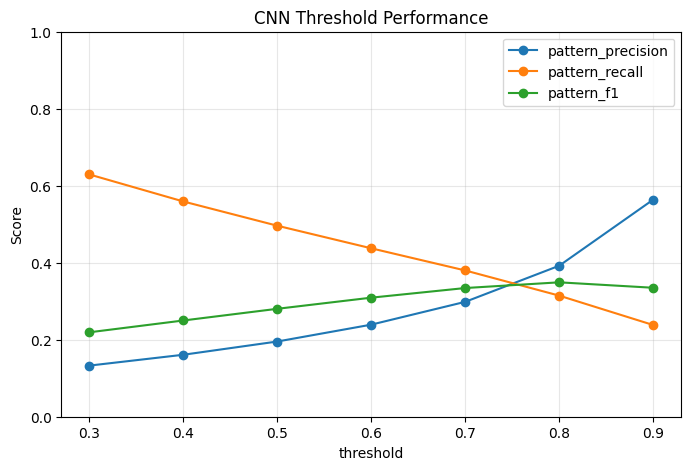

In [13]:
cnn_threshold_results.set_index("threshold")[["pattern_precision", "pattern_recall", "pattern_f1"]].plot(
    marker="o",
    figsize=(8, 5)
)

plt.title("CNN Threshold Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.show()

In [14]:
fine_threshold_results = []

thresholds = [0.70, 0.72, 0.74, 0.76, 0.78, 0.80]

for threshold in thresholds:
    y_pred_threshold = (y_proba_cnn >= threshold).astype(int)

    fine_threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred_threshold),
        "pattern_precision": precision_score(y_test, y_pred_threshold, pos_label=1, zero_division=0),
        "pattern_recall": recall_score(y_test, y_pred_threshold, pos_label=1),
        "pattern_f1": f1_score(y_test, y_pred_threshold, pos_label=1),
        "predicted_pattern_count": np.sum(y_pred_threshold == 1)
    })

fine_threshold_results = pd.DataFrame(fine_threshold_results)

display(fine_threshold_results)

,threshold,accuracy,pattern_precision,pattern_recall,pattern_f1,predicted_pattern_count
0,0.70,0.899271,0.298408,0.379909,0.334262,10050
1,0.72,0.904313,0.313579,0.368001,0.338618,9264
2,0.74,0.909440,0.331956,0.356093,0.343601,8468
3,0.76,0.913934,0.350252,0.342665,0.346417,7723
4,0.78,0.917855,0.368226,0.327084,0.346438,7012
5,0.80,0.921919,0.392135,0.314543,0.349079,6332


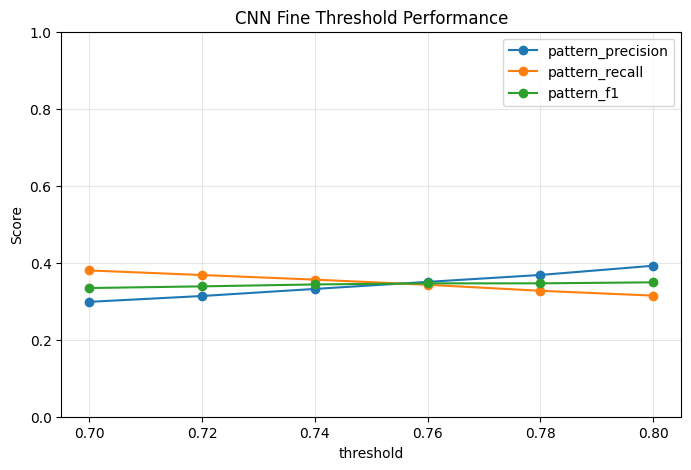

In [15]:
fine_threshold_results.set_index("threshold")[["pattern_precision", "pattern_recall", "pattern_f1"]].plot(
    marker="o",
    figsize=(8, 5)
)

plt.title("CNN Fine Threshold Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.show()

In [16]:
selected_threshold = 0.75

y_pred_cnn_selected = (y_proba_cnn >= selected_threshold).astype(int)

print(f"CNN Selected Threshold: {selected_threshold}")

print(classification_report(
    y_test,
    y_pred_cnn_selected,
    target_names=label_info["class_name"].tolist()
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_cnn_selected))

CNN Selected Threshold: 0.75
              precision    recall  f1-score   support

 non_pattern       0.95      0.95      0.95    110701
     pattern       0.34      0.35      0.34      7894

    accuracy                           0.91    118595
   macro avg       0.65      0.65      0.65    118595
weighted avg       0.91      0.91      0.91    118595

Confusion Matrix:
[[105374   5327]
 [  5142   2752]]


In [17]:
cnn_selected_result = pd.DataFrame([
    {
        "model": "CNN",
        "threshold": selected_threshold,
        "accuracy": accuracy_score(y_test, y_pred_cnn_selected),
        "pattern_precision": precision_score(y_test, y_pred_cnn_selected, pos_label=1, zero_division=0),
        "pattern_recall": recall_score(y_test, y_pred_cnn_selected, pos_label=1),
        "pattern_f1": f1_score(y_test, y_pred_cnn_selected, pos_label=1),
        "predicted_pattern_count": np.sum(y_pred_cnn_selected == 1)
    }
])

display(cnn_selected_result)

,model,threshold,accuracy,pattern_precision,pattern_recall,pattern_f1,predicted_pattern_count
0,CNN,0.75,0.911725,0.340636,0.348619,0.344581,8079


In [19]:
# baseline_compare는 02_baseline_modeling.ipynb에서 만들었던 변수

baseline_compare = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "threshold": "default",
        "accuracy": 0.57,
        "pattern_precision": 0.10,
        "pattern_recall": 0.72,
        "pattern_f1": 0.18,
        "predicted_pattern_count": None
    },
    {
        "model": "Random Forest",
        "threshold": 0.70,
        "accuracy": 0.70,
        "pattern_precision": 0.11,
        "pattern_recall": 0.49,
        "pattern_f1": 0.18,
        "predicted_pattern_count": None
    }
])

final_model_compare = pd.concat([
    baseline_compare,
    cnn_selected_result
], ignore_index=True)

display(final_model_compare)

,model,threshold,accuracy,pattern_precision,pattern_recall,pattern_f1,predicted_pattern_count
0,Logistic Regression,default,0.570000,0.100000,0.720000,0.180000,None
1,Random Forest,0.7,0.700000,0.110000,0.490000,0.180000,None
2,CNN,0.75,0.911725,0.340636,0.348619,0.344581,8079


In [20]:
final_model_compare = pd.concat([
    baseline_compare,
    cnn_selected_result
], ignore_index=True)

display(final_model_compare)

,model,threshold,accuracy,pattern_precision,pattern_recall,pattern_f1,predicted_pattern_count
0,Logistic Regression,default,0.570000,0.100000,0.720000,0.180000,None
1,Random Forest,0.7,0.700000,0.110000,0.490000,0.180000,None
2,CNN,0.75,0.911725,0.340636,0.348619,0.344581,8079


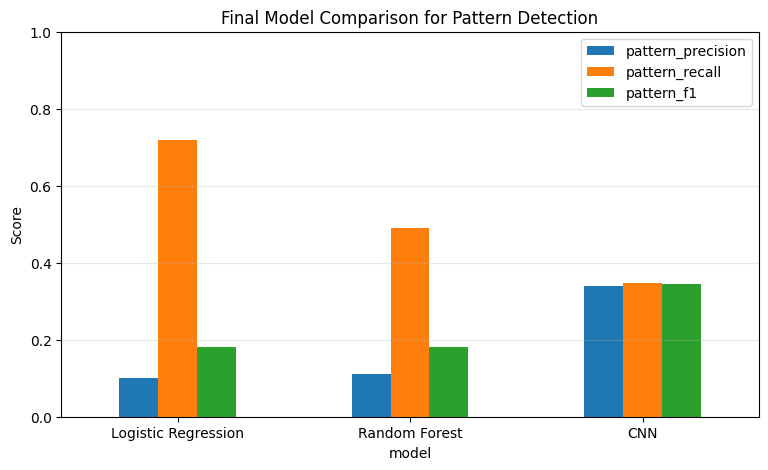

In [21]:
final_model_compare.set_index("model")[["pattern_precision", "pattern_recall", "pattern_f1"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Final Model Comparison for Pattern Detection")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

## CNN Modeling 결과 해석

CNN 모델은 32x32 wafer map의 2차원 공간 구조를 직접 학습하여 `non_pattern`과 `pattern`을 분류하도록 설계했다.

Logistic Regression과 Random Forest는 wafer map을 1차원 feature vector로 펼쳐 사용했기 때문에 위치와 주변 구조를 충분히 반영하지 못할 수 있다. 반면 CNN은 convolution layer를 통해 edge, center, scratch, local defect cluster와 같은 공간 패턴을 학습할 수 있다.

기본 threshold 0.5에서 CNN은 baseline 모델 대비 accuracy와 pattern f1-score를 개선했다. 이후 threshold를 0.3부터 0.9까지 조정하며 precision, recall, f1-score의 변화를 비교했다.

최종적으로 threshold 0.75를 선택했다. 이 지점에서는 pattern precision, pattern recall, pattern f1-score가 모두 약 0.34 수준으로 균형을 이루었다.

양산관리 관점에서는 실제 pattern wafer를 많이 탐지하는 것뿐 아니라, 과도한 오탐으로 현장 검토 부담을 키우지 않는 것도 중요하다. 따라서 threshold 0.75는 놓침과 오탐 사이의 균형을 고려한 baseline 운영 기준으로 해석할 수 있다.